# Electrical Grid Stability
## Data Understanding

### Load libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv("../data/Data_for_UCI_named.csv")

### Initial Data Inspection

In [3]:
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


### Statistical Summary

In [6]:
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


### Feature Distributions

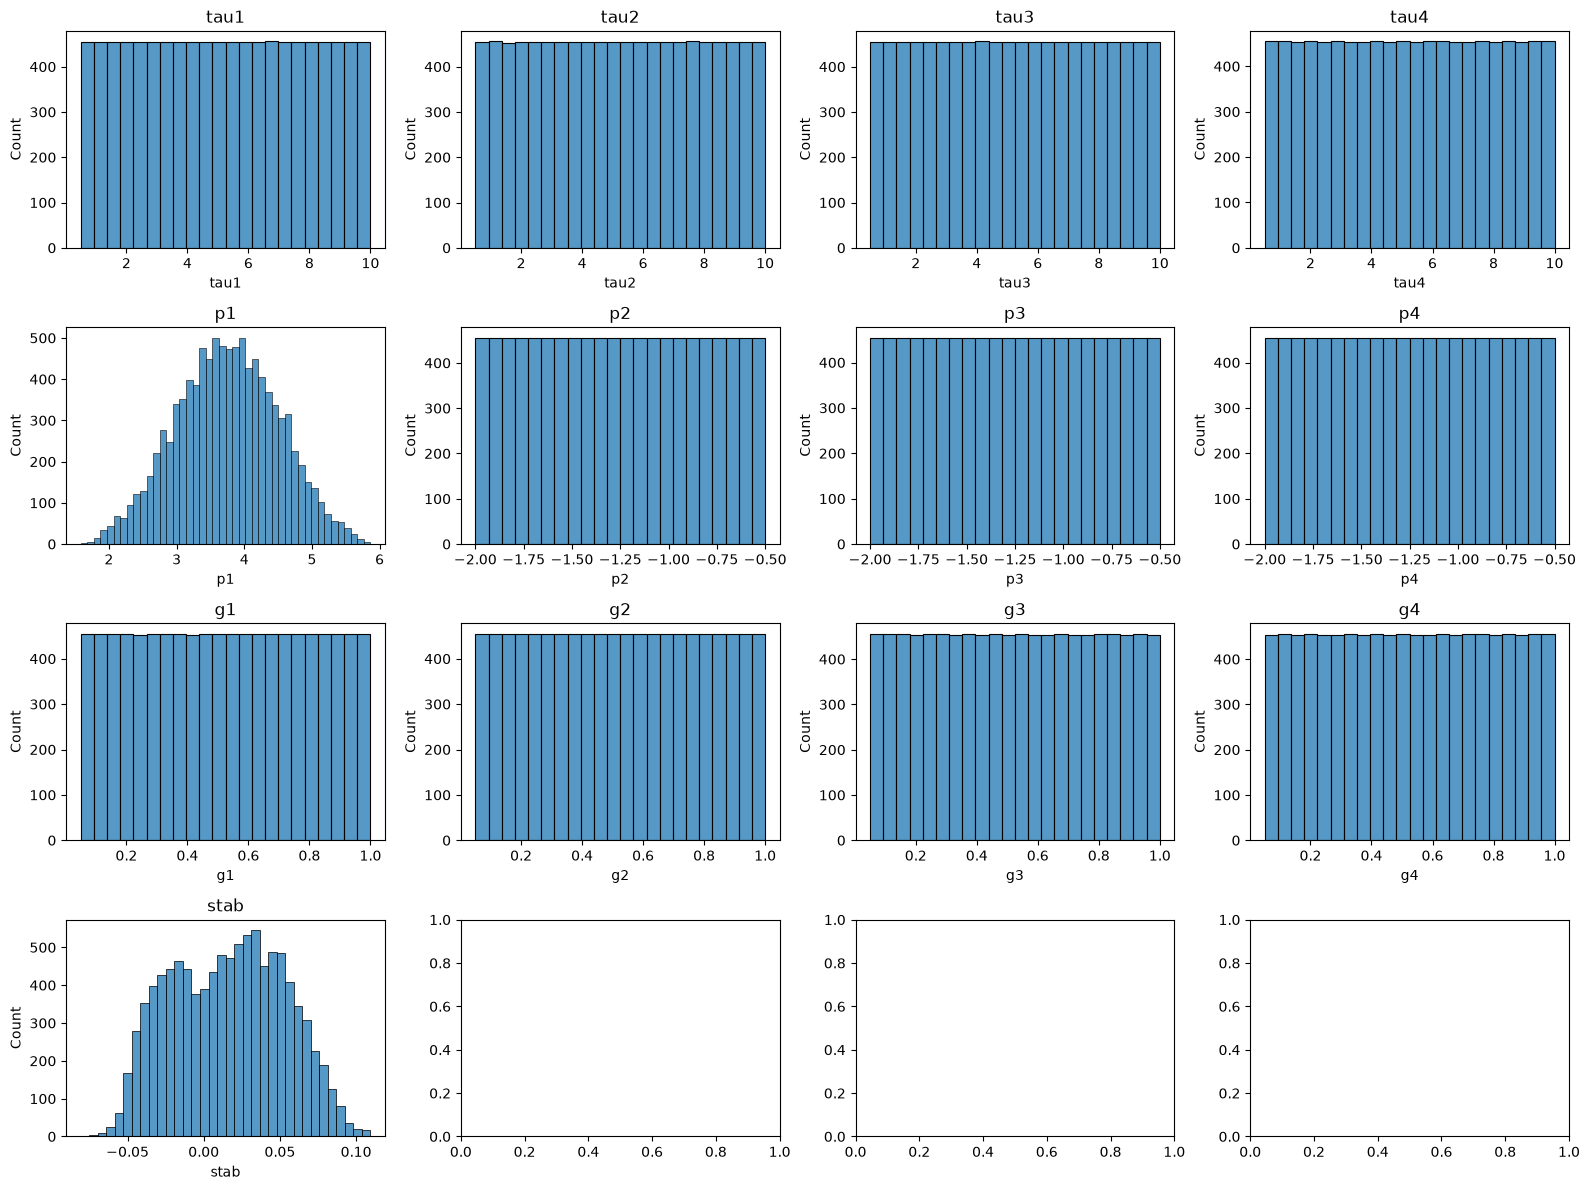

In [7]:
numerical_cols = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for col, ax in zip(numerical_cols, axes.flat):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Categorical Features

In [8]:
categorical_cols = df.select_dtypes(exclude="number").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


stabf
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


### Missing Values

In [9]:
df.isna().sum()

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

### Duplicate Rows

In [ ]:
df.duplicated().sum()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

### Duplicate Columns

In [ ]:
df.T.duplicated().sum()

tau1     False
tau2     False
tau3     False
tau4     False
p1       False
p2       False
p3       False
p4       False
g1       False
g2       False
g3       False
g4       False
stab     False
stabf    False
dtype: bool

### Unique Values

In [11]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


stabf
<StringArray>
['unstable', 'stable']
Length: 2, dtype: str


### Feature Ranges

In [12]:
df[numerical_cols].agg(["min", "max"]).T

,min,max
tau1,0.500793,9.999469
tau2,0.500141,9.999837
tau3,0.500788,9.999450
tau4,0.500473,9.999443
p1,1.582590,5.864418
p2,-1.999891,-0.500108
p3,-1.999945,-0.500072
p4,-1.999926,-0.500025
g1,0.050009,0.999937
g2,0.050053,0.999944


## Data Understanding Observations

## Data Understanding Observations

### General Observations

- The dataset contains 10,000 independent records and 14 columns.
- The dataset contains 13 numerical variables and one categorical variable.
- Each record represents the electrical grid under a specific set of operating conditions.
- The numerical features are grouped into three main groups: `tau1` to `tau4`, `p1` to `p4`, and `g1` to `g4`.
- Features within the same group have similar statistical characteristics and similar ranges.
- Most numerical features show approximately uniform distributions, while `p1` and `stab` show different distribution patterns.
- The `stab` variable is a continuous measure of the system's stability, while `stabf` represents the stability state as `stable` or `unstable`.
- The `stab` value indicates the stability state: negative values represent stable conditions, while positive values represent unstable conditions.
- The dataset contains no missing values and no duplicate rows or columns.

### Data Problems / Issues

- The `unstable` class occurs more frequently than the `stable` class in `stabf`, indicating class imbalance.
- Several features have very similar statistical characteristics, which may indicate relationships between them and requires further investigation.
- The numerical ranges and distributions of some features differ considerably, so their relationships and possible effects on the stability outcome should be investigated further.